In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import gc
import hydra
import math
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys
import tqdm
import warnings

warnings.simplefilter("ignore")

In [3]:
from src import test, train
import src.experiment as experiment

I0000 00:00:1780178011.609669 1413225 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780178012.642931 1413225 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-05-15_01-07-24/saved/checkpoint-epoch100.npy",
                                                            "+experiment=ipvae", "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [5]:
metrics

{'loss': np.float32(-62559.07),
 'loss_batch_mean': np.float32(-488.74274),
 'log_w': np.float32(56303.164),
 'log_w_batch_mean': np.float32(439.86847)}

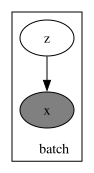

In [6]:
objects['monad'].render_model()

In [7]:
objects["monad"].parameters["log_scale"]

Array(-2.2861652, dtype=float32)

In [8]:
xs, xs_hat, zs = [], [], []

for data, _, _ in tqdm.tqdm(objects['datamodule'].test_dataloader()):
    traces = objects['monad'](data)
    recons = np.array(traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28))
    xs.append(data)
    xs_hat.append(recons)
    zs.append(np.array(traces["z"]))

    del recons
    del traces

xs = jnp.concatenate(xs, axis=0)
xs_hat = jnp.concatenate(xs_hat, axis=0)
zs = jnp.concatenate(zs, axis=1)

  0%|                                                                                                                                                                                                                  | 0/78 [00:00<?, ?it/s]E0530 14:55:43.859897 1413415 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %dot_general.1 = f32[1568,1568]{1,0} dot(%constant.14, %constant.16), lhs_contracting_dims={1}, rhs_contracting_dims={0}, metadata={op_name="jit(minimise)/while/body/jvp()/dot_general" stack_frame_id=10}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0530 14:55:45.395761 1413225 slow_operation_ala

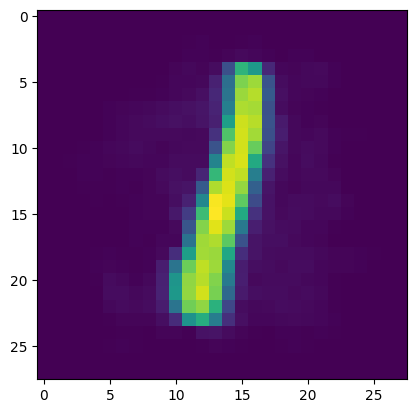

In [9]:
plt.imshow(xs_hat[0].squeeze())

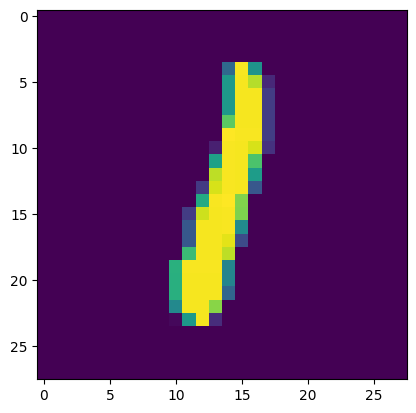

In [10]:
plt.imshow(xs[0].squeeze())

In [11]:
def r2(xs, xs_hat):
    squared_errors = ((xs - xs_hat) ** 2).sum()
    total_squares = ((xs - xs.mean(axis=0, keepdims=True)) ** 2).sum()
    return 1.0 - squared_errors / (total_squares + jnp.finfo("float64").eps)

def portion_zeros(zs):
    return (zs == 0).mean()

In [12]:
portion_zeros(zs)

Array(0.93367577, dtype=float32)

In [13]:
r2(xs, xs_hat)

Array(0.9259887, dtype=float32)

In [14]:
xs.shape

(9984, 1, 28, 28)

In [15]:
del xs
del xs_hat
del zs

In [16]:
# metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], t_total=100)

In [17]:
# metrics

In [18]:
# experiment.plot_convergence(metrics)

78it [04:21,  3.35s/it]


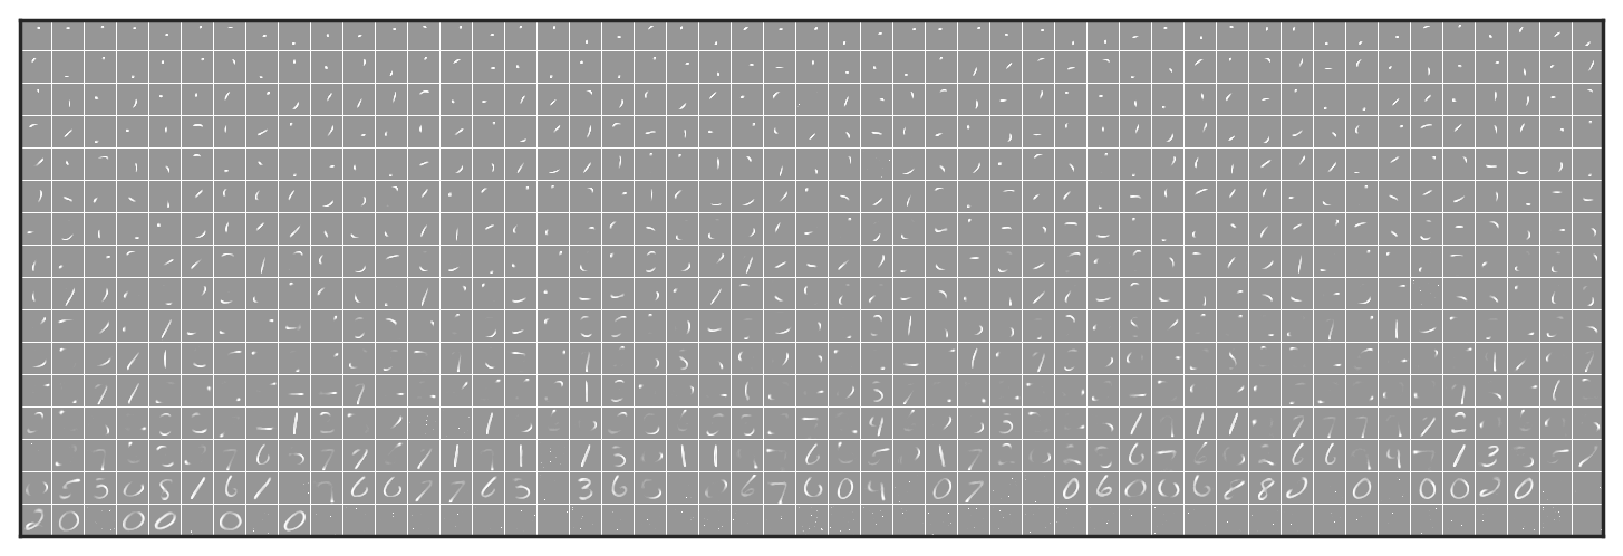

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [19]:
u_final = np.array(objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100))
u_order = np.argsort(u_final)[784:]
parameters = objects["monad"].parameters
parameters["decoder$params"]["kernel"] = parameters["decoder$params"]["kernel"] ** 2
experiment.pvae_convergence.show_decoder(objects["datamodule"], parameters, method="abs-max", order=u_order[::-1], filename="figures/ipvae_mnist_features.pdf")

In [20]:
del objects
del parameters
del u_final
del u_order

In [21]:
jax.clear_caches()

In [22]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-05-15_01-07-24/saved/checkpoint-epoch100.npy",
                                                            "+experiment=ipvae", "data=omniglot",
                                                            "trainer._target_=src.trainer.PVaeTrainer", "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [23]:
metrics

{'loss': np.float32(-62748.19),
 'loss_batch_mean': np.float32(-490.22025),
 'log_w': np.float32(56473.37),
 'log_w_batch_mean': np.float32(441.1982)}

In [24]:
xs, xs_hat, zs = [], [], []

for data, _, _ in tqdm.tqdm(objects['datamodule'].test_dataloader()):
    traces = objects['monad'](data)
    recons = np.array(traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28))
    xs.append(data)
    xs_hat.append(recons)
    zs.append(np.array(traces["z"]))

    del recons
    del traces

xs = np.concatenate(xs, axis=0)
xs_hat = np.concatenate(xs_hat, axis=0)
zs = np.concatenate(zs, axis=1)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [05:39<00:00,  3.33s/it]


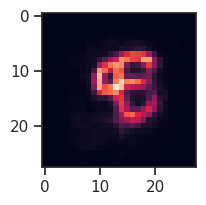

In [25]:
plt.imshow(xs_hat[0].squeeze())

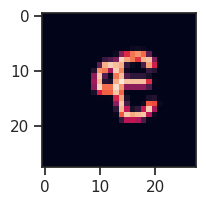

In [26]:
plt.imshow(xs[0].squeeze())

In [27]:
portion_zeros(zs)

np.float64(0.9526725094334609)

In [28]:
r2(xs, xs_hat)

np.float64(0.8351089427656362)

In [29]:
xs.shape

(13056, 1, 28, 28)

In [30]:
del xs
del xs_hat
del zs

In [31]:
# metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], t_total=100)

In [32]:
# metrics

In [33]:
# experiment.plot_convergence(metrics)

102it [05:36,  3.30s/it]


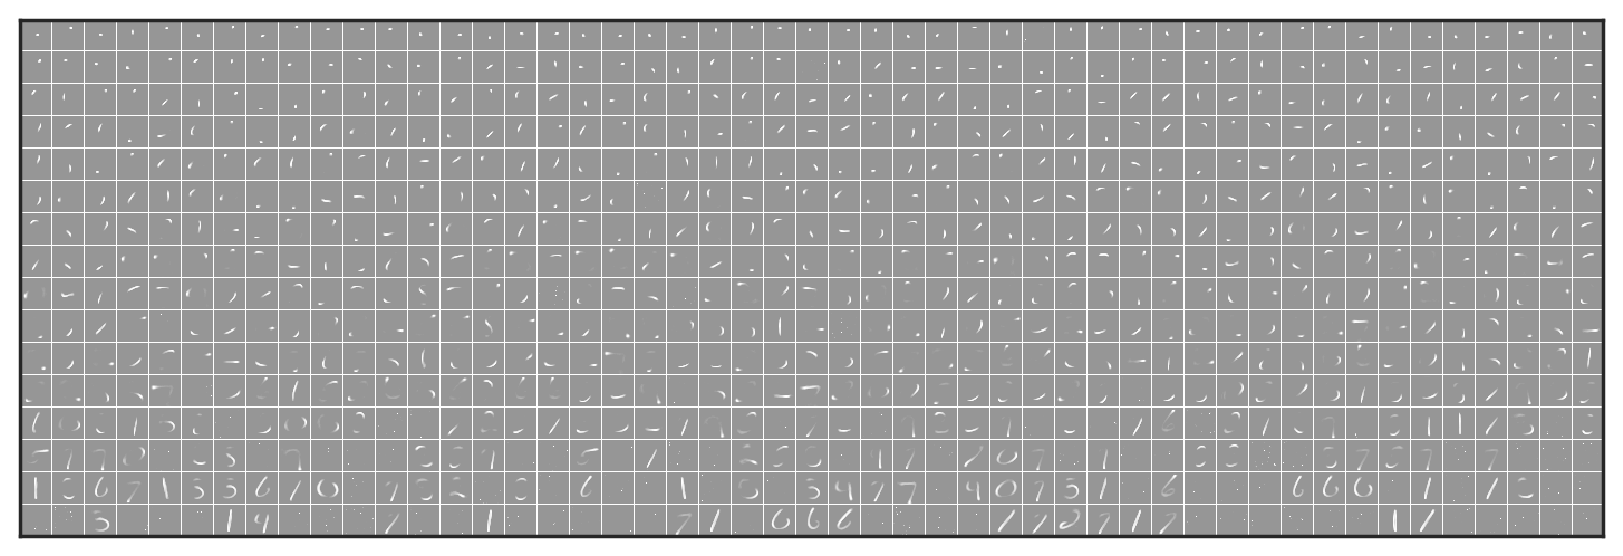

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [34]:
u_final = np.array(objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100))
u_order = np.argsort(u_final)[784:]
parameters = objects["monad"].parameters
parameters["decoder$params"]["kernel"] = parameters["decoder$params"]["kernel"] ** 2
experiment.pvae_convergence.show_decoder(objects["datamodule"], parameters, method="abs-max", order=u_order[::-1], filename="figures/ipvae_omniglot_features.pdf")

In [35]:
del objects
del parameters
del u_final
del u_order

In [36]:
jax.clear_caches()

In [37]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-05-15_01-07-24/saved/checkpoint-epoch100.npy",
                                                            "+experiment=ipvae", "data=emnist",
                                                            "trainer._target_=src.trainer.PVaeTrainer",
                                                            "hydra.runtime.output_dir=logs/test"],
                        return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [38]:
metrics

{'loss': np.float32(-21799.668),
 'loss_batch_mean': np.float32(-170.3099),
 'log_w': np.float32(19619.7),
 'log_w_batch_mean': np.float32(153.2789)}

In [39]:
xs, xs_hat, zs = [], [], []

for data, _, _ in tqdm.tqdm(objects['datamodule'].test_dataloader()):
    traces = objects['monad'](data)
    recons = np.array(traces['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28))
    xs.append(data)
    xs_hat.append(recons)
    zs.append(np.array(traces["z"]))

    del recons
    del traces

xs = np.concatenate(xs, axis=0)
xs_hat = np.concatenate(xs_hat, axis=0)
zs = np.concatenate(zs, axis=1)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 146/146 [08:12<00:00,  3.37s/it]


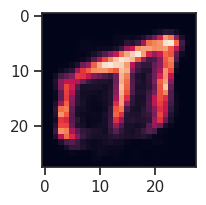

In [40]:
plt.imshow(xs_hat[0].squeeze())

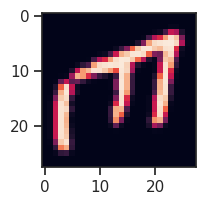

In [41]:
plt.imshow(xs[0].squeeze())

In [42]:
portion_zeros(zs)

np.float64(0.9235343372151943)

In [43]:
r2(xs, xs_hat)

np.float64(0.9088804733337382)

In [44]:
xs.shape

(18688, 1, 28, 28)

In [45]:
del xs
del xs_hat
del zs

In [46]:
# metrics = objects["trainer"].analysis(objects["datamodule"], objects["monad"], t_total=100)

In [47]:
# metrics

In [48]:
# experiment.plot_convergence(metrics)

146it [08:09,  3.35s/it]


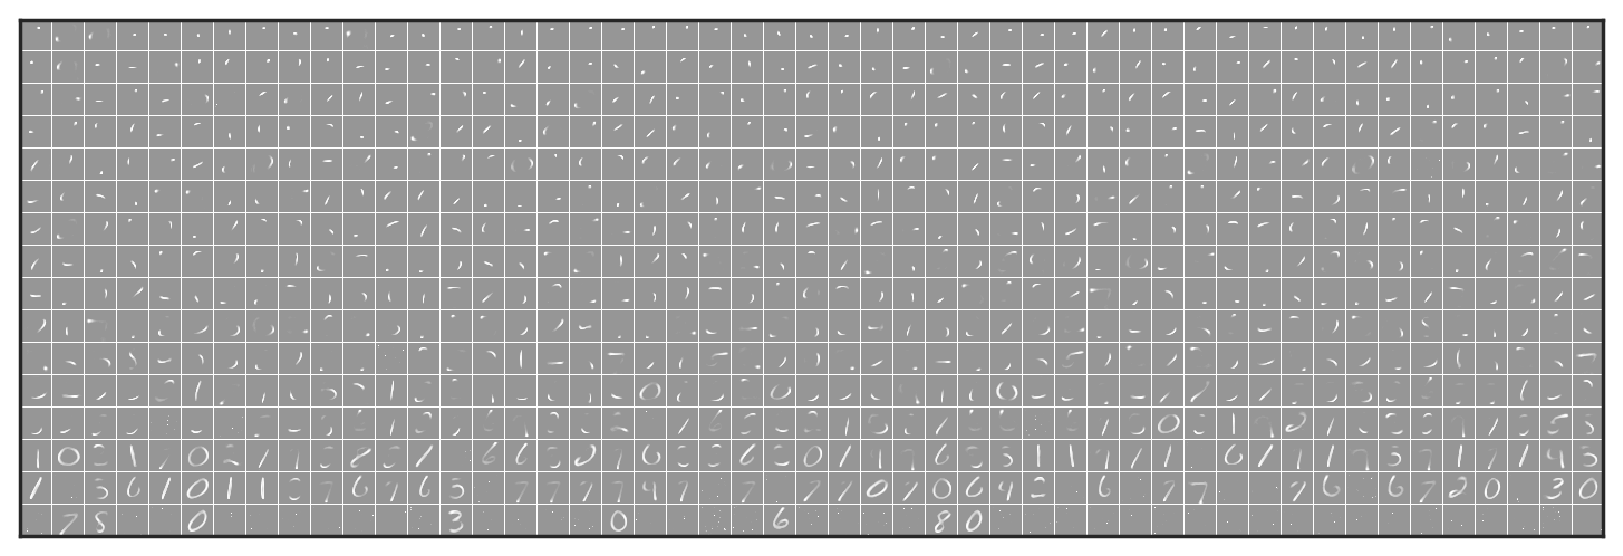

(<Figure size 1600x800 with 1 Axes>, <Axes: >)

In [49]:
u_final = np.array(objects["trainer"].proposal_us(objects["datamodule"], objects["monad"], max_steps=100))
u_order = np.argsort(u_final)[784:]
parameters = objects["monad"].parameters
parameters["decoder$params"]["kernel"] = parameters["decoder$params"]["kernel"] ** 2
experiment.pvae_convergence.show_decoder(objects["datamodule"], parameters, method="abs-max", order=u_order[::-1], filename="figures/ipvae_emnist_features.pdf")

In [50]:
del objects
del parameters
del u_final
del u_order

In [51]:
jax.clear_caches()